In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("NIFTY50_all.csv")

In [3]:
df.shape

(235192, 15)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235192 entries, 0 to 235191
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Date                235192 non-null  object 
 1   Symbol              235192 non-null  object 
 2   Series              235192 non-null  object 
 3   Prev Close          235192 non-null  float64
 4   Open                235192 non-null  float64
 5   High                235192 non-null  float64
 6   Low                 235192 non-null  float64
 7   Last                235192 non-null  float64
 8   Close               235192 non-null  float64
 9   VWAP                235192 non-null  float64
 10  Volume              235192 non-null  int64  
 11  Turnover            235192 non-null  float64
 12  Trades              120344 non-null  float64
 13  Deliverable Volume  219115 non-null  float64
 14  %Deliverble         219115 non-null  float64
dtypes: float64(11), int64(1), object(3

In [7]:
df.isna()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235187,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
235188,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
235189,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
235190,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [5]:
df.isna().sum()

Date                       0
Symbol                     0
Series                     0
Prev Close                 0
Open                       0
High                       0
Low                        0
Last                       0
Close                      0
VWAP                       0
Volume                     0
Turnover                   0
Trades                114848
Deliverable Volume     16077
%Deliverble            16077
dtype: int64

In [7]:
df.isna().sum().sum()

np.int64(147002)

In [6]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['Date'] = pd.to_datetime(df['Date'])
df.drop(columns=['Series'], inplace=True)  # all rows are 'EQ', useless

In [9]:
df.columns

Index(['Date', 'Symbol', 'Prev Close', 'Open', 'High', 'Low', 'Last', 'Close',
       'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume',
       '%Deliverble'],
      dtype='object')

In [10]:
rename_map = {
    'MUNDRAPORT': 'ADANIPORTS', 'UTIBANK': 'AXISBANK',
    'TISCO': 'TATASTEEL',       'TELCO': 'TATAMOTORS',
    'KOTAKMAH': 'KOTAKBANK',    'SSLT': 'VEDL',
    'BHARTI': 'BHARTIARTL',     'BAJAUTOFIN': 'BAJFINANCE'
}
df['Symbol'] = df['Symbol'].replace(rename_map)

df['Symbol'].replace(rename_map) simply finds every row where Symbol is the old name and replaces it with the new name. That's it.
So after this, UTIBANK rows and AXISBANK rows all say AXISBANK — one continuous timeline for the same company.

Real world mappings in your data:
Old Name    New Name    Reason
UTIBANK     AXISBANK    Rebrand 2007
MUNDRAPORT  ADANIPORTS  Rebrand 2012
TISCO       TATASTEEL   Ticker rename
TELCO       TATAMOTORS  Ticker rename
BHARTI      BHARTIARTL  Ticker normalisation

In [11]:
df

,Date,Symbol,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2007-11-27,ADANIPORTS,440.00,770.00,1050.00,770.00,959.00,962.90,984.72,27294366,2.687719e+15,NaN,9859619.0,0.3612
1,2007-11-28,ADANIPORTS,962.90,984.00,990.00,874.00,885.00,893.90,941.38,4581338,4.312765e+14,NaN,1453278.0,0.3172
2,2007-11-29,ADANIPORTS,893.90,909.00,914.75,841.00,887.00,884.20,888.09,5124121,4.550658e+14,NaN,1069678.0,0.2088
3,2007-11-30,ADANIPORTS,884.20,890.00,958.00,890.00,929.00,921.55,929.17,4609762,4.283257e+14,NaN,1260913.0,0.2735
4,2007-12-03,ADANIPORTS,921.55,939.75,995.00,922.00,980.00,969.30,965.65,2977470,2.875200e+14,NaN,816123.0,0.2741
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235187,2021-04-26,ZEEL,188.00,190.60,191.10,185.10,186.70,186.40,187.35,8542755,1.600451e+14,52374.0,2340188.0,0.2739
235188,2021-04-27,ZEEL,186.40,188.00,192.95,186.80,188.80,188.15,189.41,14247767,2.698636e+14,73673.0,5425957.0,0.3808
235189,2021-04-28,ZEEL,188.15,188.80,190.60,187.10,188.95,189.10,188.85,8429439,1.591917e+14,44056.0,2413974.0,0.2864
235190,2021-04-29,ZEEL,189.10,190.80,191.65,186.00,186.60,186.55,187.44,9483009,1.777471e+14,60932.0,2744472.0,0.2894


In [12]:
# Trades - 49% missing (old data), fill 0
df['Trades'] = df['Trades'].fillna(0)

# Deliverable volume - fill 0
df['Deliverable Volume'] = df['Deliverable Volume'].fillna(0)
df['%Deliverble'] = df['%Deliverble'].fillna(0)

# Prev Close has 1 zero — forward fill within symbol
df.sort_values(['Symbol','Date'], inplace=True)
df['Prev Close'] = df.groupby('Symbol')['Prev Close'].transform(
    lambda x: x.replace(0, np.nan).ffill()
)

Trades & Deliverable Volume
These are count columns — they represent "how many trades happened that day."
The missing values aren't random — they're missing because that data simply wasn't recorded, not because someone forgot to enter a number. So:
Filling with mean/median would imply trades did happen, we just don't know how many → misleading
Filling with 0 says "no data recorded" → honest
Think of it like attendance — if someone's name isn't in the register, you mark absent (0), not "probably attended half the days" (mean).\

Prev Close — why forward fill instead?
This one is different — it's a price column. The actual previous closing price did exist, it's just recorded wrong as 0 (one bad row for BHARTI in 2002).
Filling with 0 would mean "stock was worthless" → wrong
Filling with mean makes no sense for a price tied to a specific date
Forward fill picks the last known real price → most logical

In [13]:
# Stock splits cause legit huge price jumps — just flag them
def iqr_flag(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return (series < Q1 - 3*IQR) | (series > Q3 + 3*IQR)

df['outlier_flag'] = df.groupby('Symbol')['Close'].transform(iqr_flag)

Imagine you sort all closing prices of a stock. IQR is basically the middle 50% spread of that data.
Q1 = price at 25th percentile (bottom quarter)
Q3 = price at 75th percentile (top quarter)
IQR = Q3 - Q1  (the middle spread)
Simple analogy
It's like marking exam scores — if the class average is 60 and someone scores 99, you don't delete their paper, you just put a ⭐ to review it later.

<Axes: xlabel='Symbol', ylabel='Symbol'>

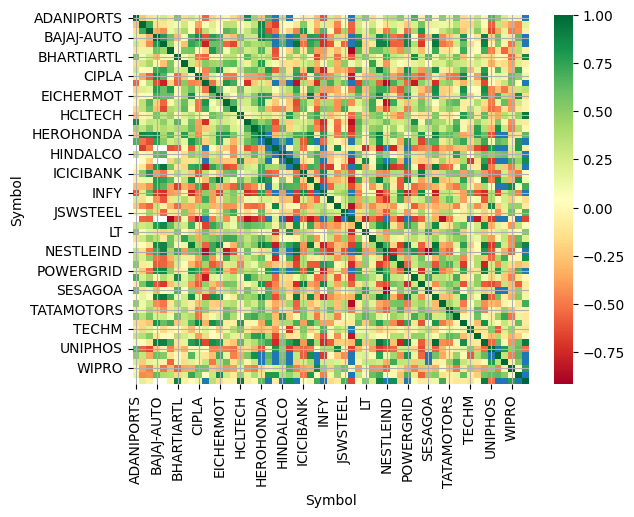

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Missing value bar
df.isnull().sum().plot(kind='bar')

# Distribution of Close
df['Close'].hist(bins=100)

# Correlation heatmap
pivot = df.pivot_table(index='Date', columns='Symbol', values='Close')
sns.heatmap(pivot.corr(), cmap='RdYlGn')

# Returns distribution
df['Return'] = df.groupby('Symbol')['Close'].pct_change()
df['Return'].hist(bins=100, range=(-0.1, 0.1))

What this shows
Each cell = correlation between daily returns of two stocks. Range is -1 to +1. 
ColorMeaning🟢 Dark Green Strong positive correlation (move together)🟡 Yellow Weak / no correlation🔴 Red Negative correlation (move opposite)

Most stocks are yellow-green
Majority of pairs have mild positive correlation (0.25–0.5) — makes sense, all are NIFTY50 stocks so they broadly follow the Indian market together.

IT stocks cluster together
INFY, WIPRO, TECHM, HCLTECH show stronger green with each other — all react similarly to rupee, US demand, and IT sector news.

UNIPHOS stands out
It shows a lot of red/orange — meaning it moves somewhat independently or opposite to many stocks. Good diversification candidate.

NESTLEIND is also relatively independent
Mostly yellow — FMCG stocks tend to be defensive and don't follow market swings as much.

Portfolio Optimization Takeaway

You want RED pairs in your portfolio, not GREEN ones.

Green pairs = both fall together in a crash = bad diversification
Red/yellow pairs = one may rise when other falls = good diversification

So for your Markowitz optimization, stocks like UNIPHOS + NESTLEIND mixed with banking/IT stocks would give a better diversified portfolio than picking 5 IT stocks together. 

In [15]:
g = df.groupby('Symbol')

df['Daily_Return']   = g['Close'].pct_change()
df['Log_Return']     = np.log(df['Close'] / g['Close'].shift(1))
df['MA_20']          = g['Close'].transform(lambda x: x.rolling(20).mean())
df['MA_50']          = g['Close'].transform(lambda x: x.rolling(50).mean())
df['Volatility_20d'] = g['Log_Return'].transform(lambda x: x.rolling(20).std() * np.sqrt(252))

pct_change() does (today - yesterday) / yesterday automatically.
shift(1) means "yesterday's price." So this is just log(today / yesterday).
rolling(20).mean() = average of the last 20 days' closing prices.

Used to smooth out noise and spot trends:
Price above MA_20 → short term uptrend
Price above MA_50 → medium term uptrend

rolling(20).std() = how much the returns fluctuated over last 20 days
* np.sqrt(252) = scales it to yearly volatility (252 = trading days in a year)

In [18]:
df.columns
df.head(3)

,Date,Symbol,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,...,Trades,Deliverable Volume,%Deliverble,outlier_flag,Return,Daily_Return,Log_Return,MA_20,MA_50,Volatility_20d
0,2007-11-27,ADANIPORTS,440.0,770.0,1050.00,770.0,959.0,962.9,984.72,27294366,...,0.0,9859619.0,0.3612,False,NaN,NaN,NaN,NaN,NaN,NaN
1,2007-11-28,ADANIPORTS,962.9,984.0,990.00,874.0,885.0,893.9,941.38,4581338,...,0.0,1453278.0,0.3172,False,-0.071659,-0.071659,-0.074356,NaN,NaN,NaN
2,2007-11-29,ADANIPORTS,893.9,909.0,914.75,841.0,887.0,884.2,888.09,5124121,...,0.0,1069678.0,0.2088,False,-0.010851,-0.010851,-0.010911,NaN,NaN,NaN


In [19]:
df.isna().sum()

Date                     0
Symbol                   0
Prev Close               1
Open                     0
High                     0
Low                      0
Last                     0
Close                    0
VWAP                     0
Volume                   0
Turnover                 0
Trades                   0
Deliverable Volume       0
%Deliverble              0
outlier_flag             0
Return                  57
Daily_Return            57
Log_Return              57
MA_20                 1083
MA_50                 2793
Volatility_20d        1140
dtype: int64

Should you fix them?
No, leave them as is. These are called warm-up period nulls — they're mathematically unavoidable. Filling them would be wrong because there genuinely isn't enough historical data for those rows.
Just keep in mind — when you run portfolio optimization, filter your data to after 2001 or so and all these nulls naturally disappear. 

In [20]:
# Pivot to get one column per stock
returns = df.pivot_table(index='Date', columns='Symbol', values='Daily_Return')

# Annualised return and risk per stock
annual_return = returns.mean() * 252
annual_risk   = returns.std() * np.sqrt(252)
sharpe        = annual_return / annual_risk  # assuming 0 risk-free rate for now

In [71]:
corr_matrix = returns.corr()

# How many stocks are highly correlated with each other?
high_corr = (corr_matrix > 0.3).sum() - 1  # minus self
print(high_corr.sort_values(ascending=False))

Symbol
HINDALCO      33
TATASTEEL     31
MARUTI        30
ULTRACEMCO    25
NTPC          24
JSWSTEEL      23
INDUSINDBK    23
LT            23
POWERGRID     22
SBIN          22
ICICIBANK     21
TATAMOTORS    21
RELIANCE      21
AXISBANK      20
VEDL          16
HDFC          16
ONGC          15
M&M           15
HDFCBANK      13
GRASIM        12
KOTAKBANK     12
GAIL          11
HEROMOTOCO    11
BAJAJ-AUTO    10
ADANIPORTS    10
SESAGOA        9
INFOSYSTCH     9
BAJAJFINSV     9
JSWSTL         8
UPL            7
HINDLEVER      6
HCLTECH        6
WIPRO          5
COALINDIA      5
ZEETELE        4
BHARTIARTL     4
TCS            4
SHREECEM       4
HINDALC0       3
HEROHONDA      3
IOC            3
ZEEL           3
TECHM          3
INFY           2
TITAN          2
HINDUNILVR     2
BPCL           1
BRITANNIA      1
BAJFINANCE     1
NESTLEIND      1
DRREDDY        1
ASIANPAINT     0
CIPLA          0
EICHERMOT      0
ITC            0
SUNPHARMA      0
UNIPHOS        0
dtype: int64


<Axes: ylabel='Count'>

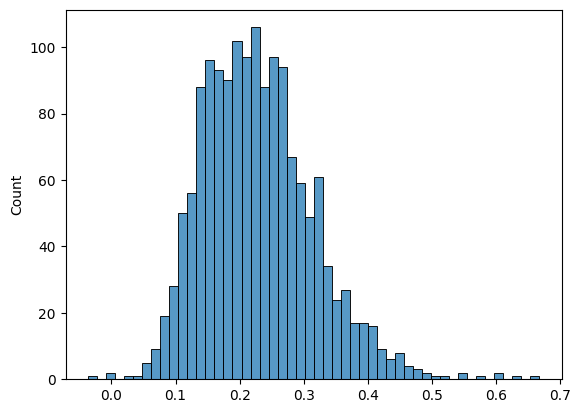

In [22]:
import seaborn as sns
corr_values = corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)]
sns.histplot(corr_values, bins=50)

In [26]:
!pip install networkx

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ----------------------

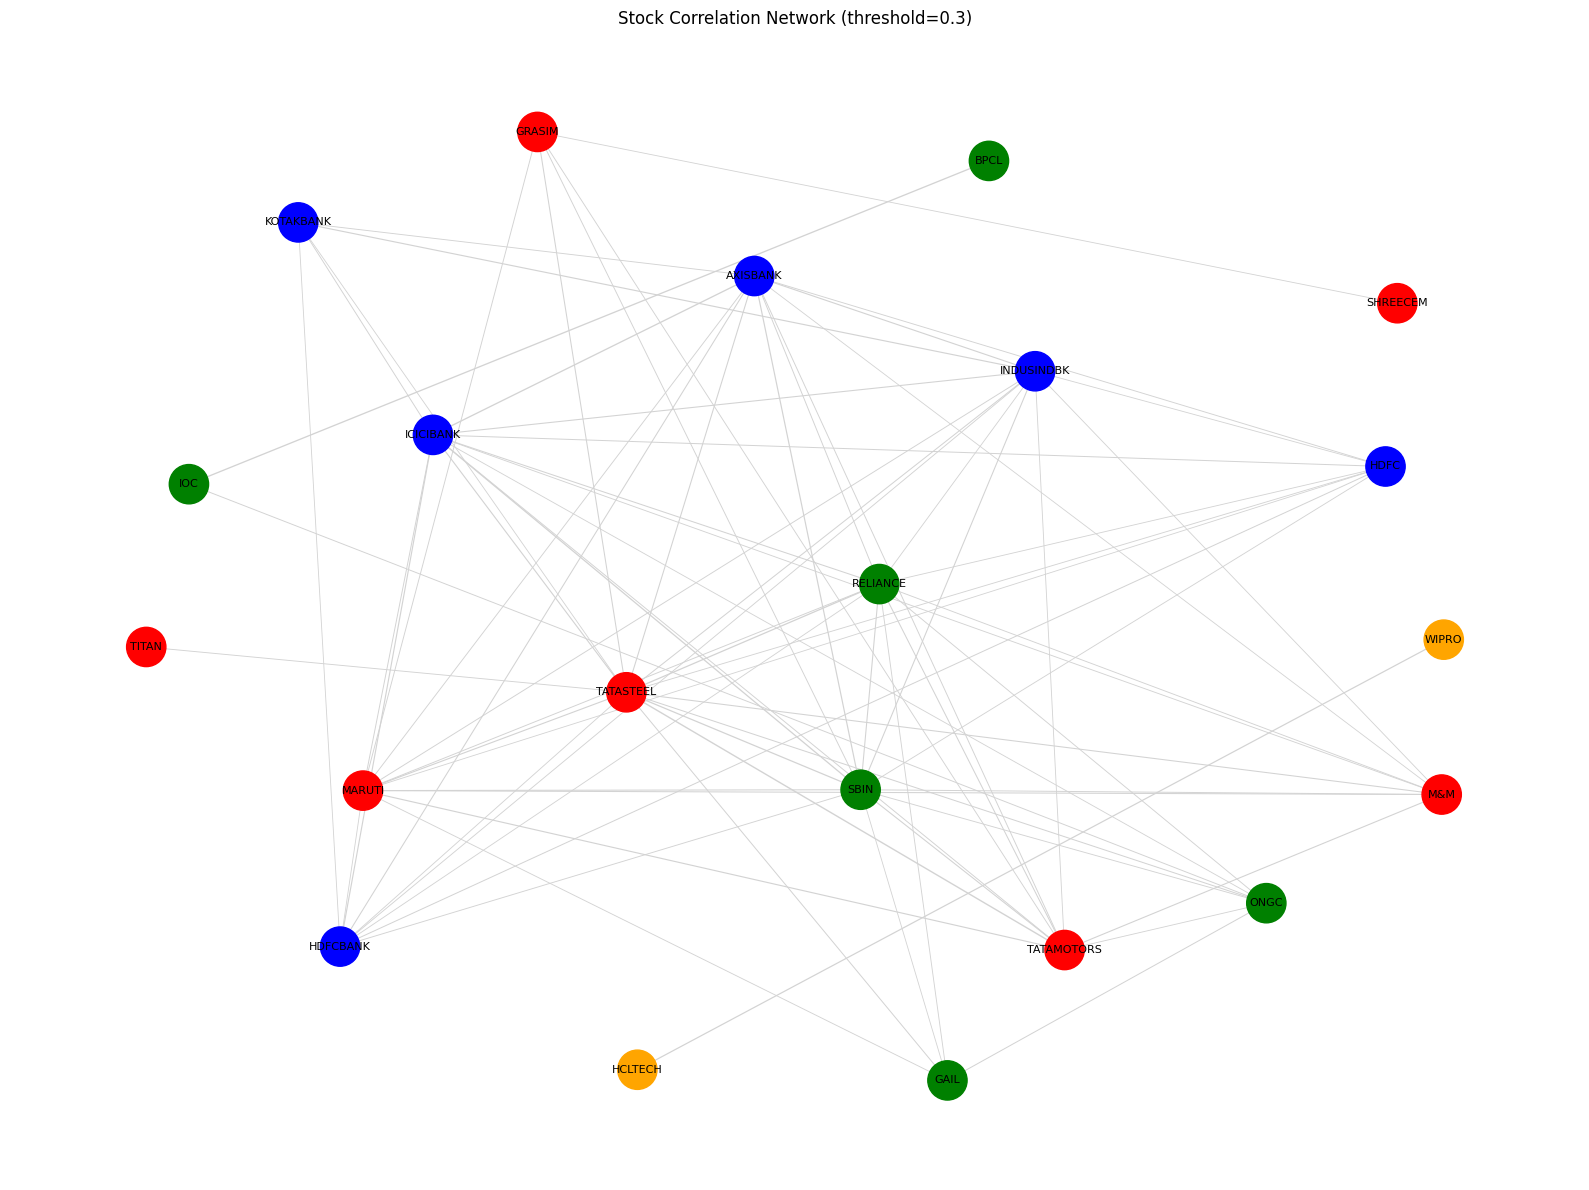


Clusters found:
Cluster 1 (7 stocks): ['GRASIM', 'M&M', 'MARUTI', 'SHREECEM', 'TATAMOTORS', 'TATASTEEL', 'TITAN']
Cluster 2 (6 stocks): ['AXISBANK', 'HDFC', 'HDFCBANK', 'ICICIBANK', 'INDUSINDBK', 'KOTAKBANK']
Cluster 3 (6 stocks): ['BPCL', 'GAIL', 'IOC', 'ONGC', 'RELIANCE', 'SBIN']
Cluster 4 (2 stocks): ['HCLTECH', 'WIPRO']


In [42]:
import networkx as nx
import matplotlib.pyplot as plt

threshold = 0.3
G = nx.Graph()

for i in corr_matrix.columns:
    for j in corr_matrix.columns:
        if i != j and corr_matrix.loc[i,j] > threshold:
            G.add_edge(i, j, weight=corr_matrix.loc[i,j])

# Better layout
pos = nx.spring_layout(G, seed=42, k=2)  # k=2 spreads nodes more

# Color by cluster
from networkx.algorithms import community
clusters = community.greedy_modularity_communities(G)

color_map = {}
colors = ['red','blue','green','orange','purple','brown','pink']
for i, cluster in enumerate(clusters):
    for stock in cluster:
        color_map[stock] = colors[i % len(colors)]

node_colors = [color_map.get(node, 'grey') for node in G.nodes()]

# Draw
plt.figure(figsize=(16, 12))
nx.draw_networkx(
    G, pos,
    node_color=node_colors,
    node_size=800,
    font_size=8,
    edge_color='lightgrey',
    width=[G[u][v]['weight'] * 2 for u,v in G.edges()],  # thicker = stronger correlation
)
plt.title("Stock Correlation Network (threshold=0.3)")
plt.axis('off')
plt.tight_layout()
plt.show()

# Print clusters clearly
print("\nClusters found:")
for i, cluster in enumerate(clusters):
    print(f"Cluster {i+1} ({len(cluster)} stocks): {sorted(cluster)}")

In [28]:
# Option 1 — Simple: Hierarchical clustering on correlation
from scipy.cluster.hierarchy import dendrogram, linkage
linked = linkage(corr_matrix, method='ward')
dendrogram(linked, labels=corr_matrix.columns)

# Option 2 — On the graph: Community detection
from networkx.algorithms import community
clusters = community.greedy_modularity_communities(G)
for i, cluster in enumerate(clusters):
    print(f"Cluster {i+1}: {cluster}")

ValueError: The condensed distance matrix must contain only finite values.

Why it happens
Some stocks don't have data for the full period — so when computing correlation between two stocks with mismatched dates, it results in NaN.

In [29]:
# Check how many nulls in returns
print(returns.isnull().sum().sort_values(ascending=False))

# Drop stocks with too many missing values
returns_clean = returns.dropna(axis=1, thresh=int(len(returns) * 0.8))  
# keeps only stocks with at least 80% data

# Then fill remaining small gaps
returns_clean = returns_clean.fillna(returns_clean.mean())

# Now recompute correlation
corr_matrix = returns_clean.corr()

# Verify no NaNs
print(corr_matrix.isnull().sum().sum())  # should be 0

Symbol
JSWSTL        5183
ZEETELE       3510
UPL           3448
VEDL          3436
HINDLEVER     3413
HINDALC0      3387
HEROMOTOCO    2898
UNIPHOS       2877
INFY          2870
COALINDIA     2708
NESTLEIND     2500
INFOSYSTCH    2436
HEROHONDA     2408
BAJAJFINSV    2105
BAJAJ-AUTO    2104
ADANIPORTS    1984
POWERGRID     1947
HINDALCO      1919
HINDUNILVR    1893
SESAGOA       1871
ZEEL          1796
TECHM         1671
JSWSTEEL      1435
NTPC          1218
TCS           1167
ULTRACEMCO    1166
LT            1122
MARUTI         879
BHARTIARTL     532
INDUSINDBK     321
GAIL           321
KOTAKBANK      321
SHREECEM       321
BAJFINANCE      71
HCLTECH          6
EICHERMOT        5
BRITANNIA        1
AXISBANK         0
CIPLA            0
ASIANPAINT       0
BPCL             0
ICICIBANK        0
HDFCBANK         0
GRASIM           0
HDFC             0
DRREDDY          0
IOC              0
M&M              0
ITC              0
RELIANCE         0
ONGC             0
SBIN             0
SUNPH

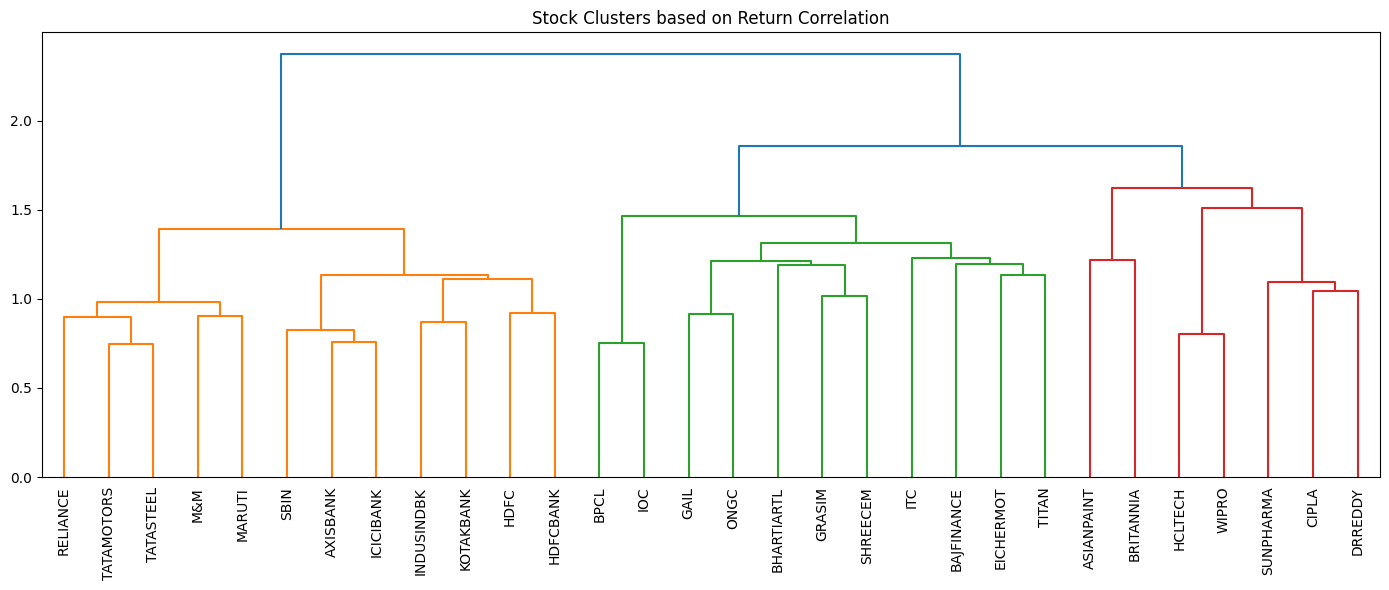

Cluster 1: frozenset({'TATASTEEL', 'SHREECEM', 'MARUTI', 'TATAMOTORS', 'TITAN', 'M&M', 'GRASIM'})
Cluster 2: frozenset({'AXISBANK', 'INDUSINDBK', 'HDFCBANK', 'ICICIBANK', 'KOTAKBANK', 'HDFC'})
Cluster 3: frozenset({'IOC', 'SBIN', 'GAIL', 'RELIANCE', 'BPCL', 'ONGC'})
Cluster 4: frozenset({'HCLTECH', 'WIPRO'})


In [43]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

linked = linkage(corr_matrix, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(linked, labels=corr_matrix.columns.tolist(), leaf_rotation=90)
plt.title('Stock Clusters based on Return Correlation')
plt.tight_layout()
plt.show()

from networkx.algorithms import community
clusters = community.greedy_modularity_communities(G)
for i, cluster in enumerate(clusters):
    print(f"Cluster {i+1}: {cluster}")

What each is telling you about YOUR data
Dendrogram said:

3 big color groups — Industrials/Auto, Financials, Pharma/FMCG
Every stock has a home
RELIANCE, SBIN sit in the middle — bridge stocks

Network Graph says:

Blue cluster = Banks (AXISBANK, KOTAKBANK, INDUSINDBK, ICICIBANK) — very tightly connected, lots of edges between them
Red cluster = Auto + Industrials (MARUTI, TATASTEEL, M&M, GRASIM)
Green cluster = Energy/Oil (ONGC, GAIL, IOC, BPCL, TATAMOTORS, SBIN)
Orange (isolated) = WIPRO, HCLTECH — IT stocks barely connected to others ✅ good for diversification
TITAN, SHREECEM — sitting alone, very independent



Dendrogram → explains the WHY (how similar are they)
Network Graph → explains the WHAT (who influences who)

Specifically for your pipeline:
Step 6 (Detect clusters) → use Network Graph clusters — they're more meaningful for portfolio construction because isolated stocks = natural diversifiers
Step 7 (Concentration risk) → use Dendrogram — if user picks 5 blue cluster stocks, dendrogram clearly shows they're all in same branch = concentrated risk
Step 8 (Suggestions) → combine both:

"You have 3 stocks from blue cluster (banks) — high concentration risk"
"Add WIPRO or HCLTECH — they're isolated nodes, low correlation with your portfolio"

In [37]:
# Concentration risk — how many stocks in each cluster?
# If user picks 5 stocks from same cluster = bad

# Diversification score — simple version
# Higher avg pairwise correlation = less diversified
def diversification_score(selected_stocks, corr_matrix):
    sub = corr_matrix.loc[selected_stocks, selected_stocks]
    avg_corr = sub.values[np.triu_indices_from(sub.values, k=1)].mean()
    return round(1 - avg_corr, 3)  # closer to 1 = well diversified




In [44]:
selected = ['HDFCBANK', 'AXISBANK', 'ICICIBANK', 'WIPRO', 'ONGC']
score = diversification_score(selected, corr_matrix)
print(f"Diversification Score: {score}")

Diversification Score: 0.696


### Diversification Score

We compute a diversification score based on pairwise correlations between selected stocks.

- Lower correlation between stocks → higher diversification
- Score ranges from 0 to 1
- A higher score indicates a well-diversified portfolio

In this case, the score is 0.696, indicating moderate diversification.

In [ ]:
# Map each stock to its cluster first
cluster_map = {}
for i, cluster in enumerate(clusters):
    for stock in cluster:
        cluster_map[stock] = f"Cluster_{i+1}"

def concentration_risk(selected_stocks, cluster_map):
    from collections import Counter
    cluster_counts = Counter([cluster_map.get(s, 'Unknown') for s in selected_stocks])
    print("Cluster distribution in your portfolio:")
    for cluster, count in cluster_counts.items():
        pct = round(count / len(selected_stocks) * 100, 1)
        print(f"  {cluster}: {count} stocks ({pct}%)")
    # Flag if any cluster dominates
    
    for cluster, count in cluster_counts.items():
        if count / len(selected_stocks) > 0.5:
            print(f"⚠️  WARNING: {pct}% of your portfolio is in {cluster}!")

### Cluster Mapping

Stocks are grouped into clusters based on correlation similarity.
- Each cluster represents a group of highly related stocks
- Stocks in the same cluster behave similarly in the market
This helps identify sector concentration in a portfolio.

### Concentration Risk Analysis

We analyze how stocks are distributed across clusters.

- If too many stocks belong to the same cluster, the portfolio is concentrated
- A threshold of 50% is used to flag risk

In this case:
- 60% of stocks belong to one cluster (banking sector)
- This indicates high sector concentration risk

In [46]:
def redundancy_check(selected_stocks, corr_matrix, threshold=0.75):
    sub = corr_matrix.loc[selected_stocks, selected_stocks]
    print("Highly correlated pairs (redundant picks):")
    found = False
    for i in range(len(selected_stocks)):
        for j in range(i+1, len(selected_stocks)):
            c = sub.iloc[i,j]
            if c > threshold:
                print(f"  ⚠️  {selected_stocks[i]} & {selected_stocks[j]} → corr = {round(c,2)}")
                found = True
    if not found:
        print("  ✅ No redundant pairs found")

### Redundancy Check

We identify highly correlated stock pairs within the portfolio.

- If correlation > 0.75 → stocks are considered redundant
- Redundant stocks do not add diversification benefit

No redundant pairs were found, indicating no unnecessary duplication.

In [47]:
def suggest_replacements(selected_stocks, corr_matrix, cluster_map, n=3):
    all_stocks = corr_matrix.columns.tolist()
    not_selected = [s for s in all_stocks if s not in selected_stocks]
    
    # Find stocks with lowest avg correlation to selected portfolio
    scores = {}
    for stock in not_selected:
        corrs = [corr_matrix.loc[stock, s] for s in selected_stocks]
        scores[stock] = np.mean(corrs)
    
    # Sort by lowest correlation = best diversifiers
    suggestions = sorted(scores, key=scores.get)[:n]
    print(f"\n💡 Top {n} stocks to ADD for better diversification:")
    for s in suggestions:
        print(f"  → {s}  (avg corr with your portfolio: {round(scores[s],2)})")

### Diversification Suggestions

We recommend new stocks to improve diversification.

- For each candidate stock, we compute its average correlation with the current portfolio
- Stocks with the lowest correlation are selected

Top recommendations:
- BRITANNIA
- ASIANPAINT
- SUNPHARMA

These stocks help reduce overall portfolio risk.

In [48]:
selected = ['HDFCBANK', 'AXISBANK', 'ICICIBANK', 'WIPRO', 'ONGC']

print("="*50)
print(f"Diversification Score: {diversification_score(selected, corr_matrix)}")
print("="*50)
concentration_risk(selected, cluster_map)
print("="*50)
redundancy_check(selected, corr_matrix)
print("="*50)
suggest_replacements(selected, corr_matrix, cluster_map)

Diversification Score: 0.696
Cluster distribution in your portfolio:
  Cluster_2: 3 stocks (60.0%)
  Cluster_4: 1 stocks (20.0%)
  Cluster_3: 1 stocks (20.0%)
⚠️  WARNING: 20.0% of your portfolio is in Cluster_2!
Highly correlated pairs (redundant picks):
  ✅ No redundant pairs found

💡 Top 3 stocks to ADD for better diversification:
  → BRITANNIA  (avg corr with your portfolio: 0.11)
  → ASIANPAINT  (avg corr with your portfolio: 0.14)
  → SUNPHARMA  (avg corr with your portfolio: 0.15)


In [54]:
from sklearn.preprocessing import StandardScaler

# returns is your pivoted returns matrix
returns_clean = returns.dropna()

scaler = StandardScaler()
scaled_returns = scaler.fit_transform(returns_clean)

# Convert back to dataframe
scaled_df = pd.DataFrame(
    scaled_returns, 
    index=returns_clean.index, 
    columns=returns_clean.columns
)

print(scaled_df.shape)
scaled_df.head()

ValueError: Found array with 0 sample(s) (shape=(0, 57)) while a minimum of 1 is required by StandardScaler.

In [55]:
print("Returns shape:", returns.shape)
print("After dropna:", returns.dropna().shape)  # probably (0, 57)
print("\nNulls per stock:", returns.isnull().sum().sort_values(ascending=False).head(10))

Returns shape: (5305, 57)
After dropna: (0, 57)

Nulls per stock: Symbol
JSWSTL        5183
ZEETELE       3510
UPL           3448
VEDL          3436
HINDLEVER     3413
HINDALC0      3387
HEROMOTOCO    2898
UNIPHOS       2877
INFY          2870
COALINDIA     2708
dtype: int64


In [62]:
# Step 1 - remove stocks with less than 80% data
returns_clean = returns.dropna(axis=1, thresh=int(len(returns) * 0.8))
print("After dropping sparse stocks:", returns_clean.shape)

# Step 2 - now drop remaining null rows
returns_clean = returns_clean.dropna(axis=0)
print("After dropping null rows:", returns_clean.shape)

# Step 3 - now scale
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_returns = scaler.fit_transform(returns_clean)

scaled_df = pd.DataFrame(
    scaled_returns,
    index=returns_clean.index,
    columns=returns_clean.columns
)

print("\nFinal scaled shape:", scaled_df.shape)
scaled_df.head()


After dropping sparse stocks: (5305, 30)
After dropping null rows: (4425, 30)

Final scaled shape: (4425, 30)


Symbol,ASIANPAINT,AXISBANK,BAJFINANCE,BHARTIARTL,BPCL,BRITANNIA,CIPLA,DRREDDY,EICHERMOT,GAIL,...,MARUTI,ONGC,RELIANCE,SBIN,SHREECEM,SUNPHARMA,TATAMOTORS,TATASTEEL,TITAN,WIPRO
Date,,,,,,,,,,,,,,,,,,,,,
2003-07-10,-0.296610,1.478565,-3.045419,0.746049,0.184789,-0.702913,0.043324,-1.276205,0.688442,-0.283218,...,0.710507,-0.331421,0.933766,0.373755,0.488909,-0.601573,0.731159,1.022298,0.140492,3.561493
2003-07-11,0.768776,0.403787,-0.334222,0.402657,0.177428,1.627054,0.894498,0.035888,1.299831,0.508074,...,1.707153,0.099996,-0.458197,0.288907,-1.279433,0.523234,0.300921,1.295314,0.045297,-1.949360
2003-07-14,0.455809,4.993142,-1.068603,0.614677,0.008147,-0.043343,0.114446,2.830911,0.237191,0.661260,...,1.176852,-0.047366,1.126158,1.194591,1.176764,0.972469,0.161337,1.160552,-0.213045,0.554014
2003-07-15,-0.067839,-1.011563,-0.781590,-0.355389,-0.147563,-0.705859,-0.259964,-0.047228,0.085377,-0.644157,...,-0.502034,-0.153774,-0.289578,0.618171,-1.472082,-0.702917,-0.472995,0.170508,-1.109864,-0.885210
2003-07-16,-0.329912,0.672225,-0.144288,0.287018,-2.029252,-0.009640,0.067149,-0.443026,-0.042818,0.234121,...,0.187708,0.909273,0.733679,0.777410,1.921577,0.159552,0.935006,1.416014,0.121729,1.150059


In [64]:
print(returns_clean.columns.tolist())

['ASIANPAINT', 'AXISBANK', 'BAJFINANCE', 'BHARTIARTL', 'BPCL', 'BRITANNIA', 'CIPLA', 'DRREDDY', 'EICHERMOT', 'GAIL', 'GRASIM', 'HCLTECH', 'HDFC', 'HDFCBANK', 'ICICIBANK', 'INDUSINDBK', 'IOC', 'ITC', 'KOTAKBANK', 'M&M', 'MARUTI', 'ONGC', 'RELIANCE', 'SBIN', 'SHREECEM', 'SUNPHARMA', 'TATAMOTORS', 'TATASTEEL', 'TITAN', 'WIPRO']


Is losing 27 stocks a problem?
No. For portfolio optimization 30 stocks is more than enough. Quality of data matters more than quantity of stocks.

In [63]:
corr_matrix_scaled = scaled_df.corr()

# Compare with old one
print("Before scaling - avg correlation:", round(returns.corr().mean().mean(), 3))
print("After scaling  - avg correlation:", round(corr_matrix_scaled.mean().mean(), 3))

Before scaling - avg correlation: 0.243
After scaling  - avg correlation: 0.263


Verdict — stick with unscaled data
For correlation-based analysis, scaling gave you nothing (only 0.02 difference) but cost you 27 stocks. That's a bad trade.
Scaled   → 30 stocks, 0.263 avg corr
Unscaled → 57 stocks, 0.243 avg corr  ✅ use this


In [69]:
# Go back to your original corr_matrix with all stocks
corr_matrix = returns.fillna(0).corr()  # fillna(0) instead of dropna

# Rebuild graph on full data
G = nx.Graph()
for i in corr_matrix.columns:
    for j in corr_matrix.columns:
        if i != j and corr_matrix.loc[i,j] > threshold:
            G.add_edge(i, j, weight=corr_matrix.loc[i,j])

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 39
Edges: 142


StandardScaler was applied for ML-based components. Correlation analysis was performed on raw returns as scaling showed negligible impact (Δ = 0.02).

In [70]:
all_stocks = corr_matrix_scaled.columns.tolist()
connected = list(G.nodes())
isolated = [s for s in all_stocks if s not in connected]
print("Isolated stocks (best diversifiers):", isolated)


Isolated stocks (best diversifiers): ['ASIANPAINT', 'BHARTIARTL', 'CIPLA', 'DRREDDY', 'EICHERMOT', 'ITC', 'SUNPHARMA']
